In [307]:
import Pkg
Pkg.activate("../../FinancialPlanner")

  Activating project at `c:\Users\matsz\programowanie\Optymalizacja_portfela\FinancialPlanner`


In [308]:
using DataFrames, TimeSeries, XLSX
using Plots
using PrettyTables
using GLM


In [309]:
function ema(x, a, initial_value)
    T = length(x) 
    result = zeros(length(x))
    result[1] = initial_value
    for t in 2:T
        result[t] = a .* x[t-1] .+ (1 - a) .* result[t-1]
    end
    return result
end

ema (generic function with 1 method)

In [310]:
include("./VARs/utils.jl")

calculate_bond_returns

In [311]:
df = DataFrame(XLSX.readtable("../data/usa_data.xlsx", "Data", infer_eltypes=true))
data_source = collapse(TimeArray(df; timestamp = :Date), Dates.quarter, first)

df = DataFrame(XLSX.readtable("../data/macro_input_cape_regressors.xlsx", "Data_CAPE", infer_eltypes=true))
data_source_macro = collapse(TimeArray(df; timestamp = :date), Dates.quarter, first)

259×8 TimeArray{Float64, 2, DateTime, Matrix{Float64}} 1961-01-01T00:00:00 to 2025-07-01T00:00:00
┌─────────────────────┬───────────┬────────────────────────┬──────────┬─────────
│                     │ inflation │ inflation.expectations │ interest │ Trend  ⋯
├─────────────────────┼───────────┼────────────────────────┼──────────┼─────────
│ 1961-01-01T00:00:00 │  0.683322 │                1.26758 │  3.08827 │      4 ⋯
│ 1961-04-01T00:00:00 │   1.31365 │                1.21625 │  3.08827 │      5 ⋯
│ 1961-07-01T00:00:00 │    1.7287 │                1.25871 │  3.08827 │      5 ⋯
│ 1961-10-01T00:00:00 │  0.963784 │                1.17236 │  3.08827 │      5 ⋯
│ 1962-01-01T00:00:00 │   1.48025 │                 1.3716 │  3.08827 │      4 ⋯
│ 1962-04-01T00:00:00 │   1.53448 │                 1.4268 │  3.08827 │      4 ⋯
│ 1962-07-01T00:00:00 │   1.30732 │                1.32146 │  3.08827 │        ⋯
│ 1962-10-01T00:00:00 │   0.75331 │                1.26884 │  3.08827 │      3 ⋯
│          

###Prepare data

In [312]:
colnames(data_source)
colnames(data_source_macro)

8-element Vector{Symbol}:
 :inflation
 Symbol("inflation.expectations")
 :interest
 Symbol("Trend Growth")
 :Z
 :Natural_rate
 Symbol("Output Gap")
 Symbol("gdp.log")

In [600]:
freq = 1

caey = inv.(data_source[:CAPE]) #.*100
excess_caey = caey .- data_source[:T_Bill]


#earnings growth
eps_growth = percentchange(data_source[:E], :log) #.* 100
E_eps_growth = ema(values(eps_growth), .025, .015)
E_eps_growth = TimeArray(timestamp(eps_growth), E_eps_growth)
eps_shocs = data[:E] .- TimeSeries.lag(data[:A])



data= merge(caey, excess_caey, eps_growth, E_eps_growth, eps_shocs)
#data = from(data, Date(1975, 01, 01))

display(returns_summarystats(data, freq))


,std,max,mean,p75th,min,skewness,p25th,autocor,kurtosis,sr,median
CAPE,0.0258,0.1505,0.0565,0.0641,0.0231,1.2583,0.0385,0.9808,0.9552,2.1888,0.0488
CAPE_T_Bill,0.0222,0.0695,0.0141,0.0307,-0.0369,-0.1442,-0.0026,0.9293,-0.757,0.6374,0.0159
E,0.1208,1.015,0.0153,0.046,-1.0702,-0.1811,-0.0105,0.648,45.0445,0.1267,0.0203
A,0.0069,0.0242,0.0146,0.0189,-0.0404,-3.8975,0.0117,0.9026,24.778,2.1013,0.0156
E_A,0.1241,1.0554,0.0007,0.0282,-1.078,0.4133,-0.0283,0.6529,44.4305,0.0059,0.0036


nothing

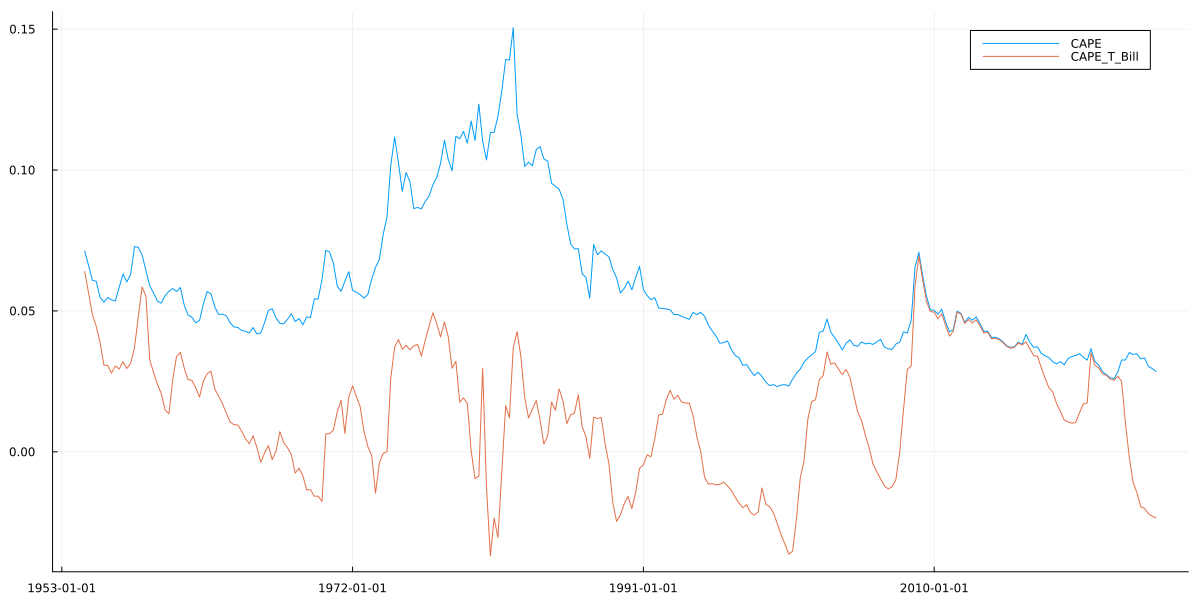

In [575]:
plot(data[:CAPE, :CAPE_T_Bill]; size=(1200,600))

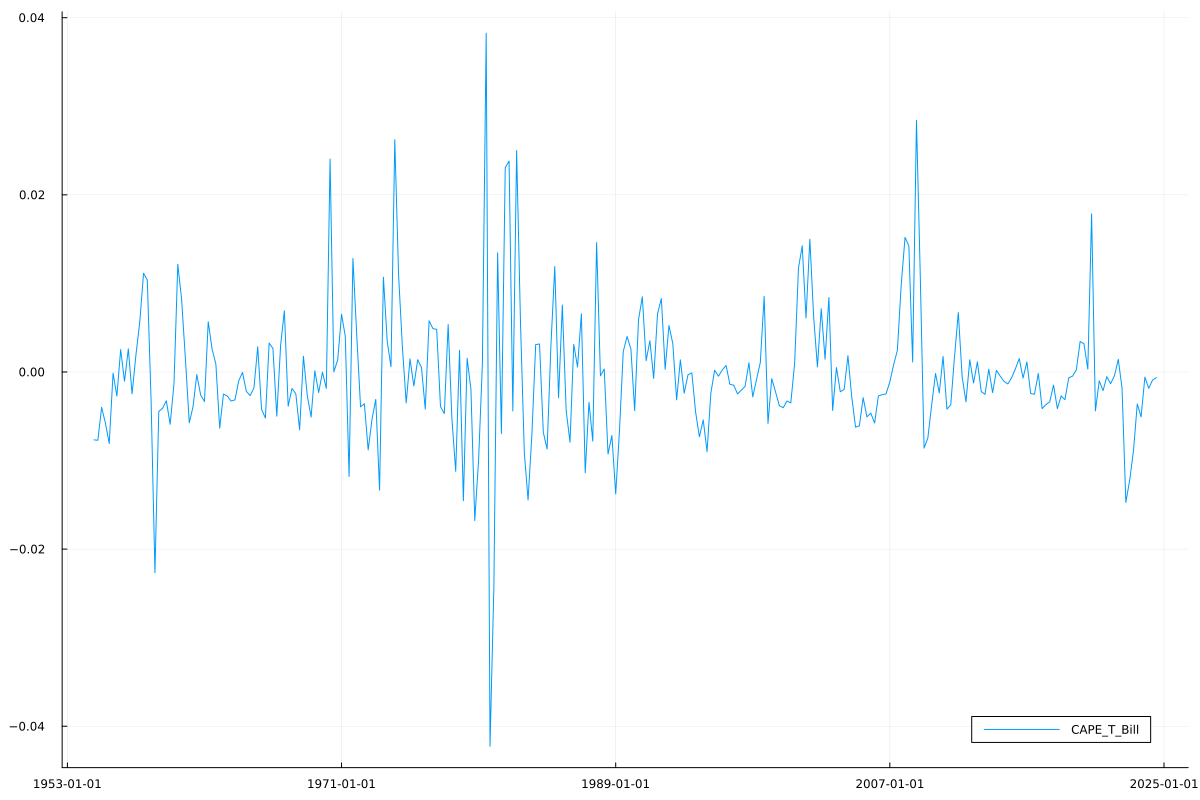

In [576]:
plot(diff(data[:CAPE_T_Bill]), size=(1200, 800))

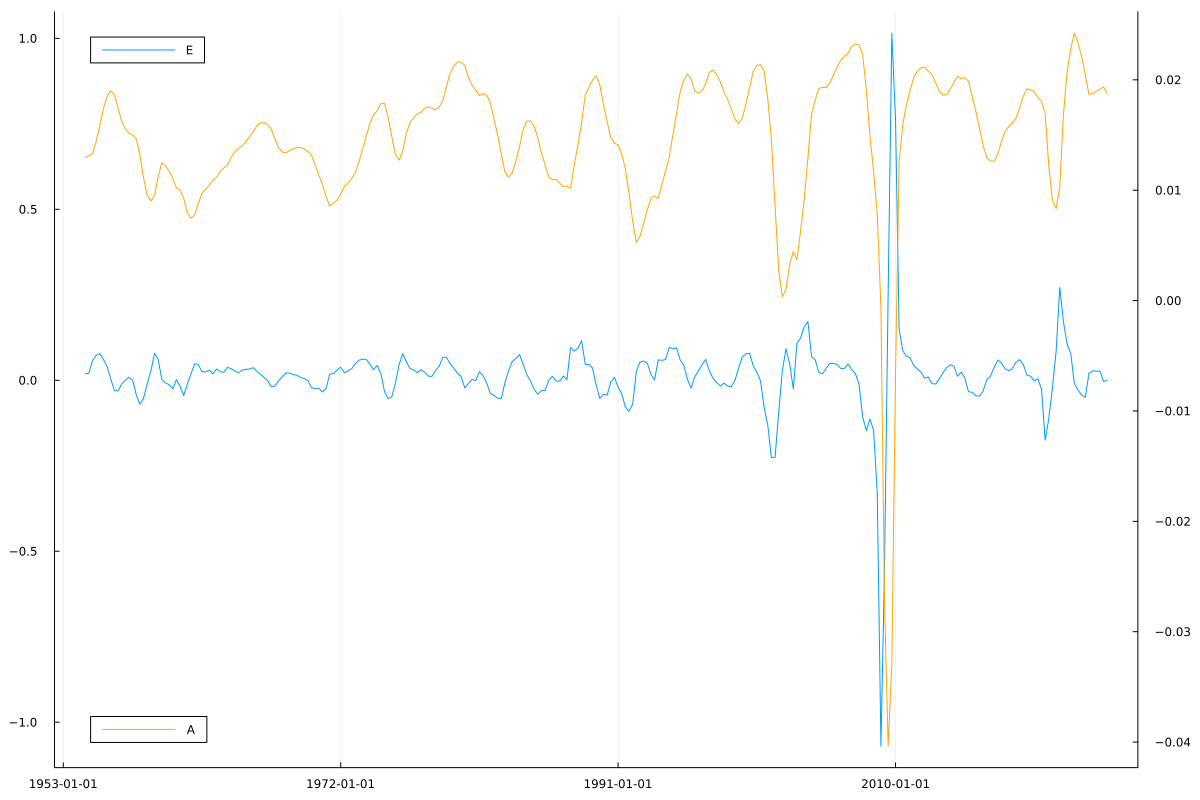

In [577]:
plot(data[:E], size=(1200, 800))
plot!(twinx(), data[:A]; color=:orange)

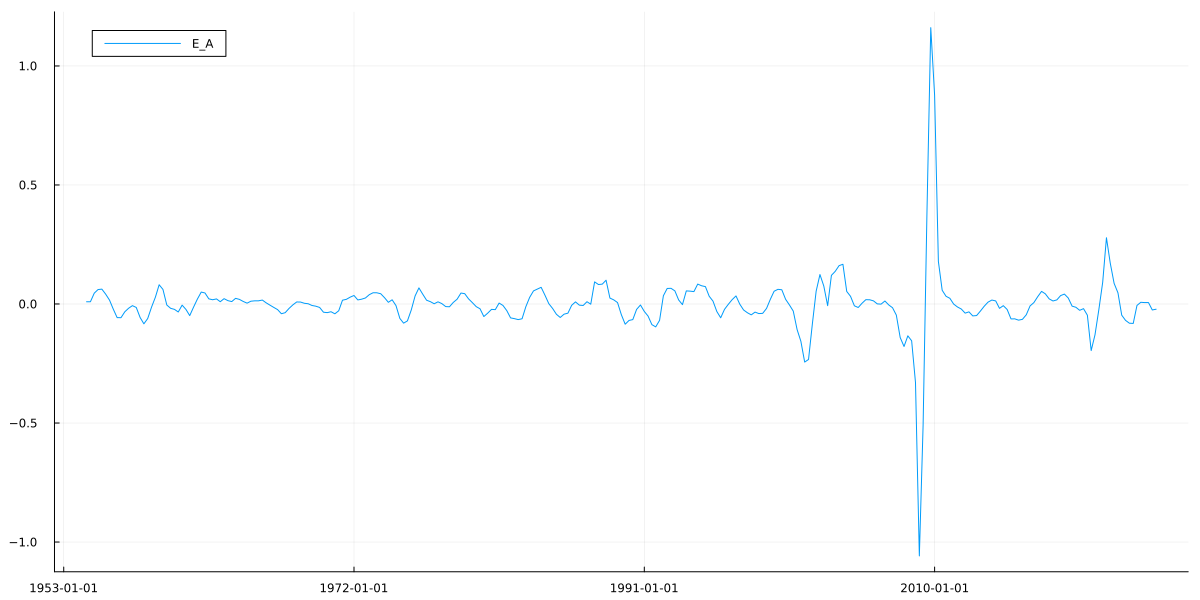

In [578]:
plot(eps_shocs, size=(1200, 600))

In [579]:
standard_data = standardize(ZScoreTransform, values(data))
standard_data = TimeArray(timestamp(data), standard_data, colnames(data))

281×5 TimeArray{Float64, 2, Date, Matrix{Float64}} 1954-07-01 to 2024-07-01
┌────────────┬───────────┬─────────────┬───────────┬────────────┬───────────┐
│            │ CAPE      │ CAPE_T_Bill │ E         │ A          │ E_A       │
├────────────┼───────────┼─────────────┼───────────┼────────────┼───────────┤
│ 1954-07-01 │   1.20444 │    0.962672 │   -0.5407 │  -0.751521 │ -0.874894 │
│ 1954-10-01 │   1.26058 │     0.88746 │ -0.491581 │  -0.758347 │ -0.898113 │
│ 1955-01-01 │  0.841102 │    0.191404 │  0.630406 │   -1.69049 │ 0.0275734 │
│ 1955-04-01 │  0.443203 │    -0.26262 │  0.978415 │   -1.60558 │  0.446578 │
│ 1955-07-01 │  0.206262 │   -0.468933 │   1.17569 │   -1.44102 │  0.528003 │
│ 1955-10-01 │  0.716469 │   -0.570053 │   1.16489 │   -1.34303 │ 0.0317292 │
│ 1956-01-01 │   1.42264 │  -0.0864606 │  0.507722 │  -0.848328 │ -0.995576 │
│ 1956-04-01 │   1.32256 │    0.400143 │ -0.428589 │  0.0842643 │  -1.37838 │
│     ⋮      │     ⋮     │      ⋮      │     ⋮     │     ⋮      │ 

In [580]:
caye_model = lm(@formula(CAPE_T_Bill~  A + E_A), standard_data) 

display(caye_model)
display(round(adjr2(caye_model); digits=4))
display(aic(caye_model))

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

CAPE_T_Bill ~ 1 + A + E_A

Coefficients:
──────────────────────────────────────────────────────────────────────────
                 Coef.  Std. Error       t  Pr(>|t|)  Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────────────────
(Intercept)  -0.898268   0.059749   -15.03    <1e-37  -1.01589   -0.78065
A            -0.467218   0.0746494   -6.26    <1e-08  -0.614168  -0.320268
E_A          -0.856566   0.0626083  -13.68    <1e-32  -0.979812  -0.733319
──────────────────────────────────────────────────────────────────────────

0.4371

456.4469643598824

In [581]:
caye_model = lm(@formula(CAPE ~  A + E_A), standard_data) 

display(caye_model)
display(round(adjr2(caye_model); digits=4))
display(aic(caye_model))

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

CAPE ~ 1 + A + E_A

Coefficients:
──────────────────────────────────────────────────────────────────────────
                 Coef.  Std. Error       t  Pr(>|t|)  Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────────────────
(Intercept)   0.619929   0.0502992   12.32    <1e-27   0.520914   0.718945
A            -0.296269   0.062843    -4.71    <1e-05  -0.419978  -0.172561
E_A          -0.667328   0.0527063  -12.66    <1e-28  -0.771082  -0.563574
──────────────────────────────────────────────────────────────────────────

0.423

359.69087160123905

### Macro variables

In [582]:
colnames(data_source_macro)

8-element Vector{Symbol}:
 :inflation
 Symbol("inflation.expectations")
 :interest
 Symbol("Trend Growth")
 :Z
 :Natural_rate
 Symbol("Output Gap")
 Symbol("gdp.log")

In [583]:
from(excess_caey, Date(1961, 01, 01))

255×1 TimeArray{Float64, 1, Date, Vector{Float64}} 1961-01-01 to 2024-07-01
┌────────────┬─────────────┐
│            │ CAPE_T_Bill │
├────────────┼─────────────┤
│ 1961-01-01 │   0.0295912 │
│ 1961-04-01 │    0.025647 │
│ 1961-07-01 │   0.0253516 │
│ 1961-10-01 │   0.0227499 │
│ 1962-01-01 │   0.0194164 │
│ 1962-04-01 │   0.0250852 │
│ 1962-07-01 │   0.0277111 │
│ 1962-10-01 │   0.0286086 │
│     ⋮      │      ⋮      │
│ 2023-01-01 │  -0.0108216 │
│ 2023-04-01 │   -0.014432 │
│ 2023-07-01 │  -0.0195019 │
│ 2023-10-01 │  -0.0200814 │
│ 2024-01-01 │  -0.0219311 │
│ 2024-04-01 │  -0.0228529 │
│ 2024-07-01 │  -0.0234948 │
└────────────┴─────────────┘
            240 rows omitted

In [584]:
macro_data

159×8 TimeArray{Float64, 2, Date, Matrix{Float64}} 1985-01-01 to 2024-07-01
┌────────────┬─────────────┬────────────┬─────────┬──────────┬───────────────┬──
│            │ CAPE_T_Bill │ A          │ g       │ y_tilde  │ inflation_exp │ ⋯
├────────────┼─────────────┼────────────┼─────────┼──────────┼───────────────┼──
│ 1985-01-01 │   0.0176841 │  0.0171985 │ 3.51992 │ -2.17909 │       3.81348 │ ⋯
│ 1985-04-01 │   0.0147674 │  0.0171244 │ 3.51477 │ -1.58119 │       4.16225 │ ⋯
│ 1985-07-01 │   0.0223203 │  0.0157043 │  3.5449 │ -1.97845 │       3.86191 │ ⋯
│ 1985-10-01 │   0.0179687 │  0.0125682 │ 3.64137 │ -1.61277 │       3.94823 │ ⋯
│ 1986-01-01 │   0.0100219 │ 0.00855666 │ 3.58761 │ -1.77921 │       3.95415 │ ⋯
│ 1986-04-01 │   0.0131461 │ 0.00565293 │  3.5552 │ -1.37801 │       3.67617 │ ⋯
│ 1986-07-01 │   0.0137063 │ 0.00298259 │ 3.48304 │ -1.77768 │       3.49313 │ ⋯
│ 1986-10-01 │   0.0202825 │ 0.00277587 │ 3.50215 │ -1.81211 │       3.15647 │ ⋯
│     ⋮      │      ⋮      │     

In [609]:
#macro variables#output trend growth, output gap, inltation trend, inflation gap, z, interest rate gap, term?
interest_rate_gap = data_source_macro[:interest] .- data_source_macro[:Natural_rate] .- data_source_macro[Symbol("inflation.expectations")] 
inflation_gap = data_source_macro[:inflation] .- data_source_macro[Symbol("inflation.expectations")] 

macro_data = merge(data_source_macro[Symbol("Trend Growth")], data_source_macro[Symbol("Output Gap")], data_source_macro[Symbol("inflation.expectations")], inflation_gap, data_source_macro[:Z], interest_rate_gap)
macro_data = TimeArray(macro_data; 
                        timestamp=Date.(timestamp(macro_data)), 
                        colnames=[:g, :y_tilde, :inflation_exp, :inflation_gap, :z, :interest_gap])
                   
macro_data = merge(excess_caey, TimeSeries.lag(E_eps_growth), TimeSeries.lag(macro_data))

macro_data = from(macro_data, Date(1985,01,01))
 
display(returns_summarystats(macro_data, 1))
cor_matrix = cor(values(macro_data))
display(cor_matrix[1:4,:])
display(cor_matrix[5:8,5:8])

,std,max,mean,p75th,min,skewness,p25th,autocor,kurtosis,sr,median
CAPE_T_Bill,0.0239,0.0695,0.012,0.0298,-0.0363,-0.0013,-0.0108,0.9632,-0.9496,0.5,0.0137
A,0.0087,0.0242,0.0149,0.0197,-0.0404,-3.556,0.0123,0.8946,17.1352,1.7048,0.0174
g,0.7027,3.8522,2.5971,3.2329,1.2761,-0.2196,2.0608,0.9837,-1.0124,3.696,2.7088
y_tilde,1.9619,7.2313,0.6514,1.8095,-2.6941,1.0292,-0.6433,0.9392,1.751,0.332,0.4527
inflation_exp,1.0687,5.3688,2.3456,3.1194,0.6644,0.9717,1.5735,0.962,-0.0295,2.1948,1.9535
inflation_gap,0.5598,2.1864,-0.0095,0.2541,-1.7285,0.2537,-0.3351,0.1613,1.9577,-0.017,0.003
z,0.3944,0.0348,-0.55,-0.2683,-1.7389,-0.7874,-0.869,0.9519,-0.115,-1.3946,-0.4093
interest_gap,1.7873,2.5485,-1.003,0.5505,-6.7294,-0.3626,-2.2702,0.9383,-0.0109,-0.5612,-1.1835


nothing

4×8 Matrix{Float64}:
  1.0        -0.400738  -0.711645  …   0.0582617  -0.286733   -0.705351
 -0.400738    1.0        0.104907     -0.17492    -0.0680095   0.217397
 -0.711645    0.104907   1.0          -0.0197702   0.617982    0.569035
  0.0333466   0.380839  -0.358245      0.329881   -0.595373   -0.463167

4×4 Matrix{Float64}:
  1.0        -0.0449156  0.20092     0.113725
 -0.0449156   1.0        0.0630123  -0.181802
  0.20092     0.0630123  1.0         0.354752
  0.113725   -0.181802   0.354752    1.0

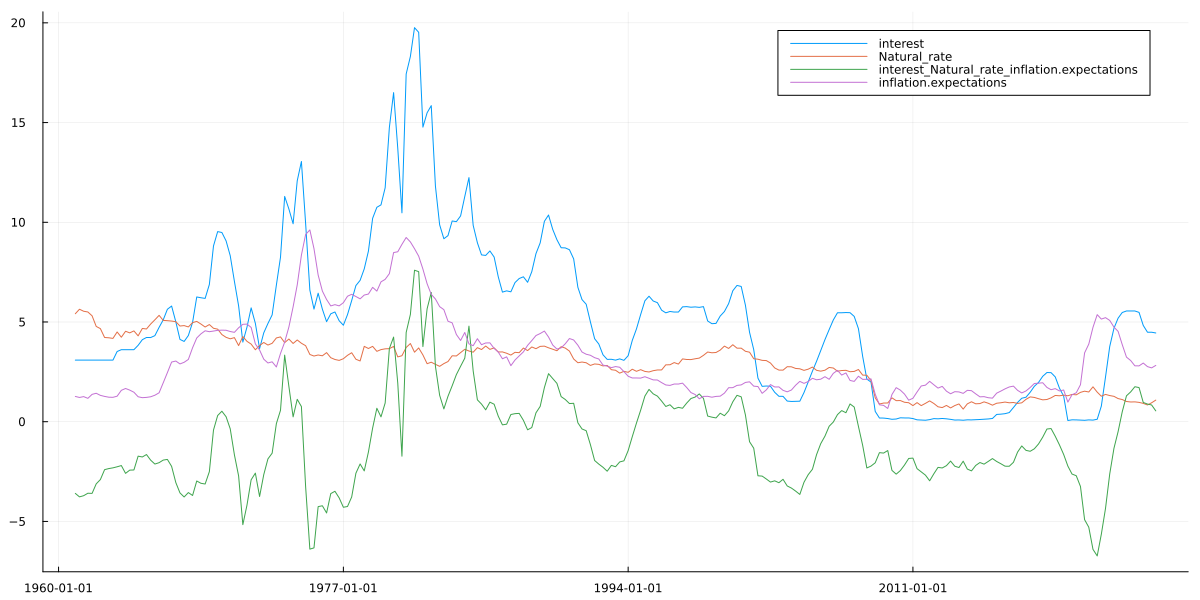

In [586]:
plot(data_source_macro[:interest], size=(1200,600))
plot!(data_source_macro[:Natural_rate])
plot!(interest_rate_gap)
plot!(data_source_macro[Symbol("inflation.expectations")])

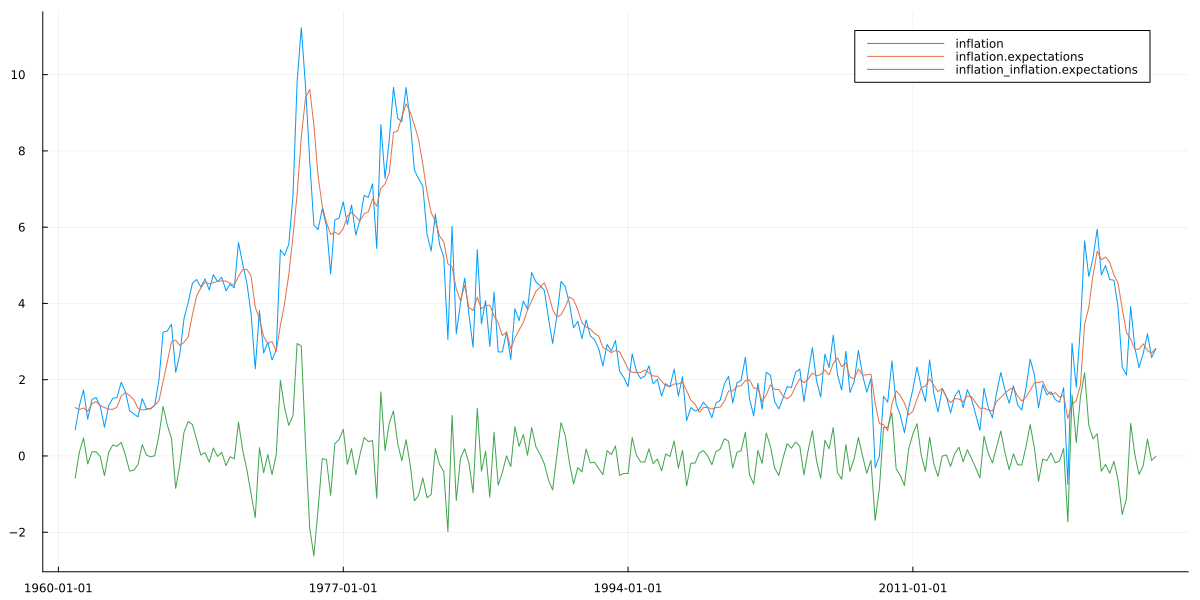

In [587]:
plot(data_source_macro[:inflation, Symbol("inflation.expectations")], size=(1200,600))
plot!(inflation_gap)

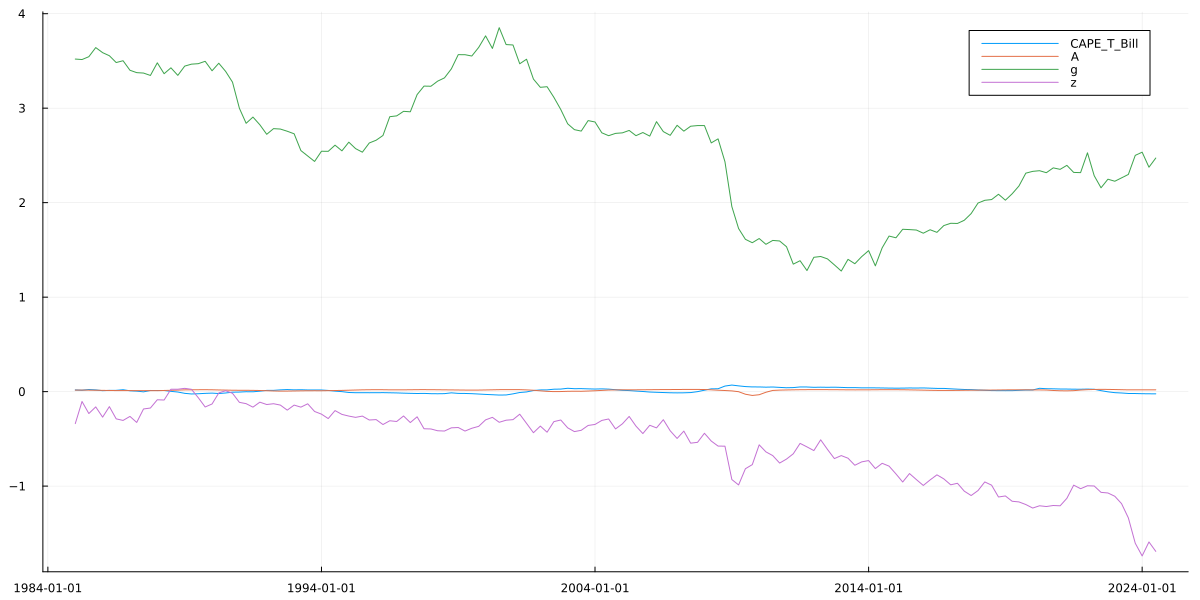

In [588]:
plot(macro_data[[:CAPE_T_Bill, :A, :g, :z]], size=(1200,600))

In [589]:
standard_data = standardize(ZScoreTransform, values(macro_data))
standard_data = TimeArray(timestamp(macro_data), standard_data, colnames(macro_data))

159×8 TimeArray{Float64, 2, Date, Matrix{Float64}} 1985-01-01 to 2024-07-01
┌────────────┬─────────────┬───────────┬──────────┬────────────┬────────────────
│            │ CAPE_T_Bill │ A         │ g        │ y_tilde    │ inflation_exp ⋯
├────────────┼─────────────┼───────────┼──────────┼────────────┼────────────────
│ 1985-01-01 │   -0.356613 │ -0.357257 │  1.23138 │   -1.35268 │       1.36448 ⋯
│ 1985-04-01 │   -0.532911 │ -0.532138 │  1.27627 │   -1.35788 │       1.61096 ⋯
│ 1985-07-01 │   -0.344319 │ -0.347556 │  1.40749 │   -1.33931 │       1.56514 ⋯
│ 1985-10-01 │   -0.413167 │ -0.414816 │  1.45078 │   -1.25205 │       1.60864 ⋯
│ 1986-01-01 │   -0.320969 │ -0.319357 │  1.40106 │    -1.1822 │       1.57749 ⋯
│ 1986-04-01 │   -0.493513 │ -0.493992 │  1.47255 │   -1.26569 │        1.5397 ⋯
│ 1986-07-01 │   -0.282743 │ -0.284036 │  1.52566 │   -1.21651 │       1.53092 ⋯
│ 1986-10-01 │   -0.259028 │ -0.264086 │  1.62812 │   -1.25217 │       1.44077 ⋯
│     ⋮      │      ⋮      │     

In [590]:
colnames(macro_data)


8-element Vector{Symbol}:
 :CAPE_T_Bill
 :A
 :g
 :y_tilde
 :inflation_exp
 :inflation_gap
 :z
 :interest_gap

In [591]:
caye_model = lm(@formula(CAPE_T_Bill ~ g + inflation_exp + z), standard_data) 

display(caye_model)
display(round(adjr2(caye_model); digits=4))
display(aic(caye_model))

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

CAPE_T_Bill ~ 1 + g + inflation_exp + z

Coefficients:
───────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error      t  Pr(>|t|)  Lower 95%  Upper 95%
───────────────────────────────────────────────────────────────────────────
(Intercept)     0.567065   0.0813941   6.97    <1e-10   0.40628    0.72785
g              -0.223195   0.0321114  -6.95    <1e-10  -0.286628  -0.159763
inflation_exp  -0.202302   0.039299   -5.15    <1e-06  -0.279932  -0.124671
z               0.508162   0.0480136  10.58    <1e-19   0.413317   0.603008
───────────────────────────────────────────────────────────────────────────

0.4955

-94.66957952598827

In [592]:
caye_model = lm(@formula(CAPE_T_Bill ~ g + A + z + inflation_exp), macro_data) 

display(caye_model)
display(round(adjr2(caye_model); digits=4))
display(aic(caye_model))
res = residuals(caye_model)
sqrt(res' * res)


StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

CAPE_T_Bill ~ 1 + g + A + z + inflation_exp

Coefficients:
───────────────────────────────────────────────────────────────────────────────────
                      Coef.  Std. Error       t  Pr(>|t|)    Lower 95%    Upper 95%
───────────────────────────────────────────────────────────────────────────────────
(Intercept)     0.100935     0.00711394   14.19    <1e-29   0.0868813    0.114988
g              -0.0266674    0.0022538   -11.83    <1e-22  -0.0311198   -0.0222151
A              -0.828339     0.138377     -5.99    <1e-07  -1.1017      -0.554976
z               0.0110215    0.00381896    2.89    0.0045   0.00347714   0.0185658
inflation_exp  -0.000569971  0.00119458   -0.48    0.6339  -0.00292986   0.00178992
──────────────────────────────────────────────────────────────────────────────────

0.6249

-884.5499634176691

0.1819859232462753

In [593]:
caye_model = lm(@formula(CAPE_T_Bill ~ g + A + z + inflation_exp), standard_data) 

display(caye_model)
display(round(adjr2(caye_model); digits=4))
display(aic(caye_model))
res = residuals(caye_model)
sqrt(res' * res)


StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

CAPE_T_Bill ~ 1 + g + A + z + inflation_exp

Coefficients:
───────────────────────────────────────────────────────────────────────────────────
                      Coef.  Std. Error       t  Pr(>|t|)    Lower 95%    Upper 95%
───────────────────────────────────────────────────────────────────────────────────
(Intercept)     0.0341117    0.00501391    6.80    <1e-09   0.0242068    0.0440167
g              -0.00833349   0.00198756   -4.19    <1e-04  -0.0122599   -0.00440709
A               1.07097      0.00469536  228.09    <1e-99   1.06169      1.08024
z               0.00243873   0.00342986    0.71    0.4781  -0.00433692   0.00921438
inflation_exp  -0.000788934  0.00231694   -0.34    0.7339  -0.00536603   0.00378816
────────────────────────────────────────────────────────────────────────────────

0.9985

-1018.9226020239428

0.11926809663045422

In [594]:
stand_std = sqrt(res' * res)
stand_std * 0.0233

0.0027789466514895837

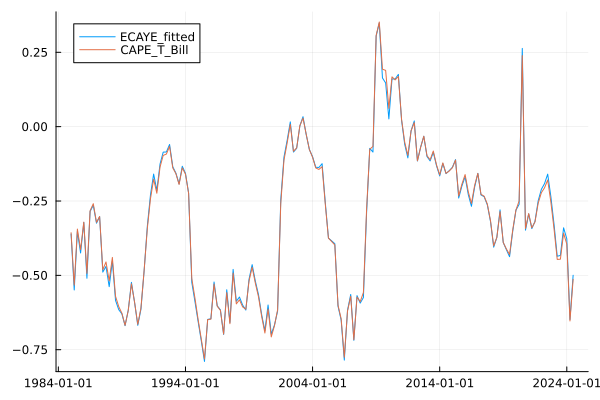

In [595]:
predicted = predict(caye_model)
predicted = TimeArray(timestamp(macro_data), predicted, [:ECAYE_fitted])

plot(predicted)
plot!(standard_data[:CAPE_T_Bill])

In [596]:
Not(colnames(standard_data), :CAPE_T_Bill)

InvertedIndex{InvertedIndices.NotMultiIndex}(InvertedIndices.NotMultiIndex(([:CAPE_T_Bill, :A, :g, :y_tilde, :inflation_exp, :inflation_gap, :z, :interest_gap], :CAPE_T_Bill)))

In [597]:
split_date = Date(2014, 12, 31)
train = to(standard_data, split_date)
test= from(standard_data, split_date)

caye_model = lm(@formula(CAPE_T_Bill ~ g + A  + z), train) 
display(caye_model)
display(round(adjr2(caye_model); digits=4))

predicted = predict(caye_model, test)
predicted = TimeArray(timestamp(test), predicted, [:ECAYE_fitted])

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

CAPE_T_Bill ~ 1 + g + A + z

Coefficients:
───────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error       t  Pr(>|t|)   Lower 95%    Upper 95%
───────────────────────────────────────────────────────────────────────────────
(Intercept)   0.0406086   0.00399641   10.16    <1e-17   0.0326932   0.048524
g            -0.015656    0.00259505   -6.03    <1e-07  -0.0207958  -0.0105162
A             1.07423     0.00503986  213.15    <1e-99   1.06424     1.08421
z            -0.00709011  0.00509093   -1.39    0.1664  -0.0171733   0.00299312
───────────────────────────────────────────────────────────────────────────────

0.9989

39×1 TimeArray{Union{Missing, Float64}, 1, Date, Vector{Union{Missing, Float64}}} 2015-01-01 to 2024-07-01
┌────────────┬──────────────┐
│            │ ECAYE_fitted │
├────────────┼──────────────┤
│ 2015-01-01 │     -0.12965 │
│ 2015-04-01 │    -0.104127 │
│ 2015-07-01 │    -0.232476 │
│ 2015-10-01 │    -0.191963 │
│ 2016-01-01 │     -0.16095 │
│ 2016-04-01 │    -0.220326 │
│ 2016-07-01 │    -0.259632 │
│ 2016-10-01 │    -0.195463 │
│     ⋮      │      ⋮       │
│ 2023-01-01 │     -0.31978 │
│ 2023-04-01 │    -0.424347 │
│ 2023-07-01 │    -0.421191 │
│ 2023-10-01 │    -0.329093 │
│ 2024-01-01 │    -0.365334 │
│ 2024-04-01 │    -0.633731 │
│ 2024-07-01 │    -0.486645 │
└────────────┴──────────────┘
              24 rows omitted

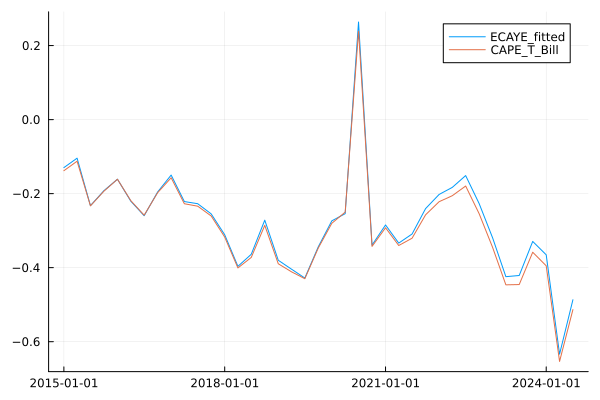

In [598]:
plot(predicted)
plot!(test[:CAPE_T_Bill])

#### TODO i wątpliwości
- wspólna skaala z macro variables (eps i caye * 100)
- co jeśli dodamy lagged eps shock
- eps growth zamiast eps shock
- [+] eps expected growth 
- out of sample prediction, predyckcja na koniec 2014 i 2019
- okres estymacji - po 85 r
- regresja na gasp a nie trend - output gap, inflation gap, interest rate gap
- [+] unit root standarisation a nie normalisation
- sprawdzic wszystkie daty, czy sa dobrze zrobione
- uporzadkowac notebook
- zrobić symulację?
- model dla eps polaczony z rstar estimation
- performe regression before normalisation
- plot predicted and test data after reconstruction standarysation

### spotstrzezenia
- lepszy fit jest na normalised data